In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# CIFAR-10 (32x32)

# Transforms definitions
train_transform = transforms.Compose([
    transforms.Resize(224), # upscale [32,32] -> [224, 224]
    transforms.RandomHorizontalFlip(), # change right and left
    transforms.ToTensor(), # 0-255 -> 0-1.0
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)) # mean(s) are all 0.5, std are all 0.5
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

# Dataset loading
os.makedirs('./data', exist_ok=True)
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

# DataLoader definitinos
BATCH_SIZE = 128
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True # GPU transportation speed up
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

shape torch.Size([128, 3, 224, 224])


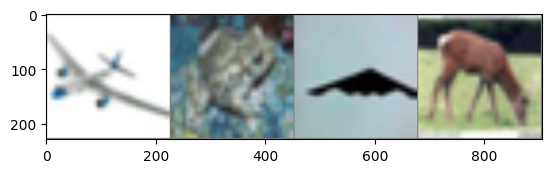

labels : plane frog plane deer


In [3]:
def imshow(img):
    img = img / 2 + 0.5 # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.show()

# get 1 batch
dataiter = iter(train_loader)
images, labels = next(dataiter)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print('shape', images.shape)
imshow(torchvision.utils.make_grid(images[:4]))
print(f'labels : {" ".join(classes[labels[j]] for j in range(4))}')